In [9]:
# ---- Cell 1: library import----
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import h5py
from pathlib import Path

In [25]:
# ---- Cell 2: Select Path ----

hdf5_dir = Path("/scratch/yimili/matrices/hdf5")
name     = "carbon-nanotube"          # change per notebook
material = name 
h5path   = hdf5_dir / f"{name}.h5"


In [26]:
# ---- Cell 3: load everything ----
def _load_sparse(g):
    shape = tuple(g.attrs["shape"]) if "shape" in g.attrs else None
    return sp.csc_matrix((g["data"][:], g["indices"][:], g["indptr"][:]), shape=shape)

with h5py.File(h5path, "r") as f:
    indices  = f["metadata/indices"][:].tolist()
    energies = f["metadata/energies"][:]
    
    H = (f["global/H"])[:]
    S = (f["global/S"])[:]
    
    max_singular_values = f["global/max_singular_values"][:]
    min_singular_values = f["global/min_singular_values"][:]
    kappa               = f["global/condition_full_svd"][:]

    M   = {idx: _load_sparse(f[f"E_{idx}/M"])     for idx in indices}
    Sig = {idx: _load_sparse(f[f"E_{idx}/Sigma"]) for idx in indices}
    rhs = {idx: f[f"E_{idx}/rhs"][:]              for idx in indices}
    w   = {idx: f[f"E_{idx}/spectrum"][:]         for idx in indices}

idx_arr = np.array(indices)
M_arr_sp = np.array([M[idx] for idx in idx_arr])

print(name, "| n_energies =", len(indices), "| E[-1] =", energies[-1])
print(idx_arr)
print(H.shape, H.dtype)

carbon-nanotube | n_energies = 402 | E[-1] = -2.5999999999999996
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 23

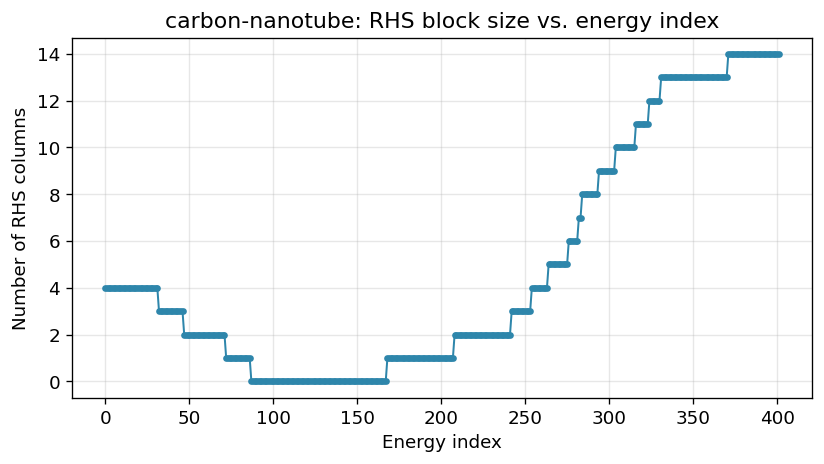

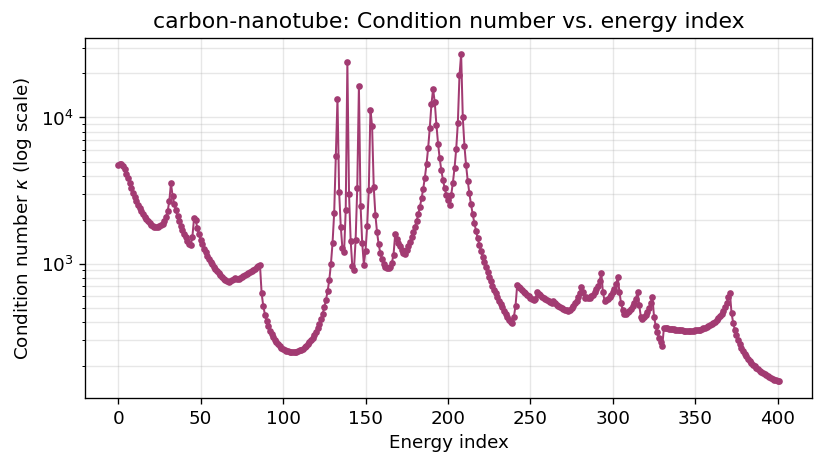

In [27]:
# ---- Cell 4: Plot data ----
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# ---------- Plot rhs size ----------
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(idx_arr, [rhs[idx].shape[-1] for idx in idx_arr],
        marker="o", markersize=3, linewidth=1.2, color="#2E86AB")
ax.set_xlabel("Energy index")
ax.set_ylabel("Number of RHS columns")
ax.set_title(f"{name}: RHS block size vs. energy index")
fig.tight_layout()
# fig.savefig("rhs_shape.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- Plot condition number (log scale) ----------
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(idx_arr, [kappa[idx] for idx in idx_arr],
        marker="o", markersize=3, linewidth=1.2, color="#A23B72")
ax.set_yscale("log")
ax.set_xlabel("Energy index")
ax.set_ylabel(r"Condition number $\kappa$ (log scale)")
ax.set_title(f"{name}: Condition number vs. energy index")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
# fig.savefig("kappa.png", dpi=150, bbox_inches="tight")
plt.show()

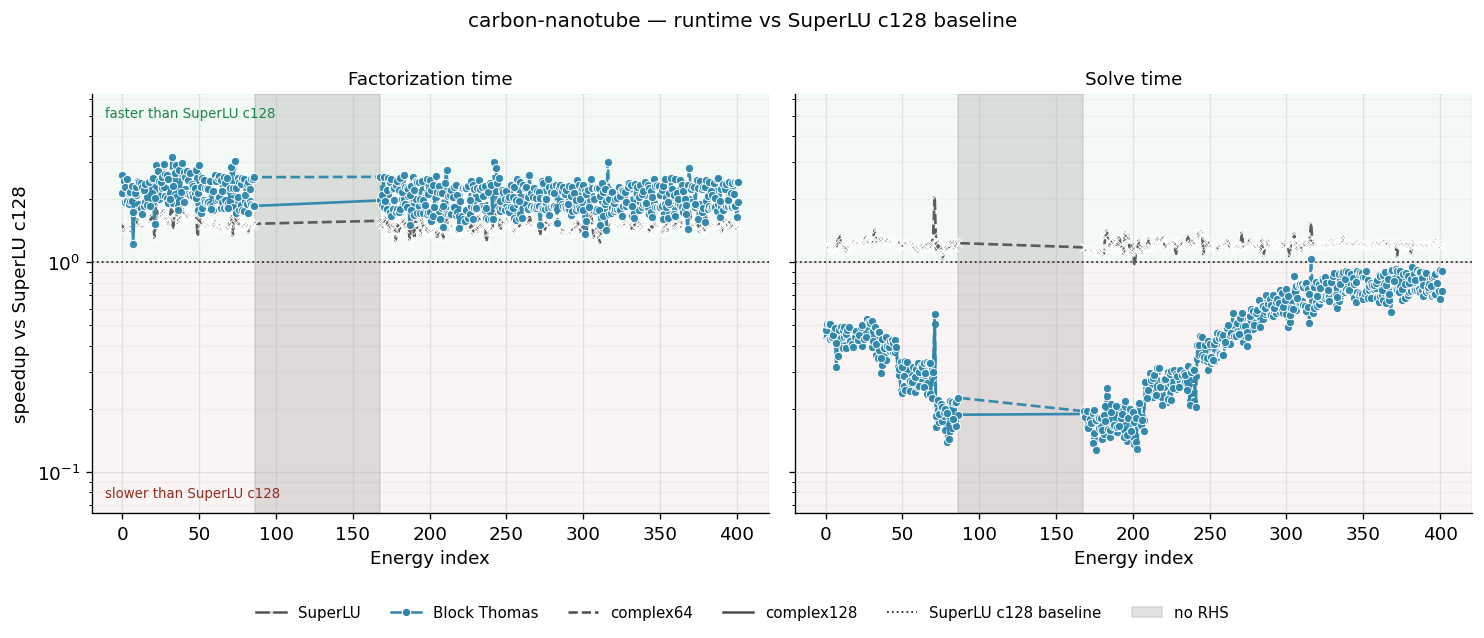

In [28]:
# =============================================================================
# ---- Cell 7: runtime comparison, all solvers x all dtypes vs SuperLU c128 ----
# ---- reads timings straight out of h5path -- no dependency on `metrics` ----
# =============================================================================
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PRIMARY = "c128"                       # baseline = superlu at this dtype
DTYPE_LS = {"c128": "-", "c64": "--"}  # linestyle per precision
DTYPE_NAME = {"c128": "complex128", "c64": "complex64"}   # suffix -> HDF5 group name

# solver base name -> (legend label, color, marker)
STYLE = {
    "superlu":      ("SuperLU",       "#555555", "x"),
    #"umfpack":      ("UMFPACK",       "#E67E22", "s"),
    #"mumps":        ("MUMPS",         "#27AE60", "^"),
    #"gmres":        ("GMRES (SciPy)", "#8E44AD", "D"),
    #"gmres_cupy":   ("GMRES (CuPy)",  "#C0392B", "v"),
    #"cudss":        ("cuDSS",         "#16A085", "P"),
    "block_thomas": ("Block Thomas",  "#2E86AB", "o"),
}

# STYLE keys are the plot's own naming; the actual HDF5 group a solver's
# results are saved under can differ (factor_io / bench_all hardcode their
# own group names independently). Map plot key -> real on-disk group name.
GROUP_NAME = {
    "superlu":      "superlu",
    #"umfpack":      "umfpack",
    #"mumps":        "mumps",
    #"gmres":        "gmres_scipy",   # bench_all saves this one as "gmres_scipy"
    #"gmres_cupy":   "gmres_cupy",
    #"cudss":        "cudss",
    "block_thomas": "blockthomas",   # factor_io.save_blockthomas has no underscore
}


def _read_times(f, idx, solver, sfx):
    """(time_fact, time_solve) for E_<idx>/<solver>/<dtype>, or None if that
    (solver, dtype, idx) combination was never run / saved. `solver` is the
    STYLE key -- translated to the real HDF5 group name via GROUP_NAME."""
    path = f"E_{int(idx)}/{GROUP_NAME.get(solver, solver)}/{DTYPE_NAME[sfx]}"
    g = f.get(path)
    if g is None or "time_fact" not in g or "time_solve" not in g:
        return None
    return float(g["time_fact"][()]), float(g["time_solve"][()])


def _speedup_series(f, indices, solver, sfx, field):
    """(indices, baseline_time / solver_time) where this solver+dtype ran,
    read straight from the HDF5 groups."""
    fi = 0 if field == "factor" else 1
    pts = []
    for idx in indices:
        base = _read_times(f, idx, "superlu", PRIMARY)
        cur = _read_times(f, idx, solver, sfx)
        if base is None or cur is None or cur[fi] <= 0:
            continue
        pts.append((idx, base[fi] / cur[fi]))
    if not pts:
        return [], []
    xs, ys = zip(*pts)
    return list(xs), list(ys)


with h5py.File(h5path, "r") as f:
    # universe of energy indices: prefer metadata/indices (the full sweep,
    # including any that had no RHS and so were never benched); fall back to
    # whatever E_<idx> groups actually exist in the file.
    if "metadata/indices" in f:
        sweep = f["metadata/indices"][:].tolist()
    else:
        sweep = sorted(int(k[2:]) for k in f.keys() if k.startswith("E_"))

    solved_indices = sorted(
        idx for idx in sweep if _read_times(f, idx, "superlu", PRIMARY) is not None
    )
    skipped = np.array(sorted(set(sweep) - set(solved_indices)))

    # y-limits from the data itself (the shading below must not drive autoscale)
    all_speedups = [y for field in ("factor", "solve") for solver in STYLE
                    for sfx in DTYPE_LS
                    for y in _speedup_series(f, solved_indices, solver, sfx, field)[1]]
    ymin = min(all_speedups + [1.0]) / 2.0
    ymax = max(all_speedups + [1.0]) * 2.0

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=True, sharey=True)

    plotted_solvers, plotted_dtypes = [], []
    for ax, field, panel in zip(axes, ["factor", "solve"],
                                ["Factorization time", "Solve time"]):
        for solver, (label, color, marker) in STYLE.items():
            for sfx, ls in DTYPE_LS.items():
                if solver == "superlu" and sfx == PRIMARY:
                    continue                       # identically 1 -- it IS the baseline
                xs, ys = _speedup_series(f, solved_indices, solver, sfx, field)
                if not xs:
                    continue
                ax.plot(xs, ys, color=color, marker=marker, ls=ls,
                        markersize=5, markeredgecolor="white", markeredgewidth=0.6,
                        lw=1.6, alpha=0.95, zorder=3)
                if solver not in plotted_solvers:
                    plotted_solvers.append(solver)
                if sfx not in plotted_dtypes:
                    plotted_dtypes.append(sfx)

        # baseline + faster/slower context shading (kept inside ylim)
        ax.axhline(1.0, color="0.2", lw=1.1, ls=":", zorder=2)
        ax.axhspan(1.0, ymax, color="#27AE60", alpha=0.05, zorder=0)
        ax.axhspan(ymin, 1.0, color="#C0392B", alpha=0.05, zorder=0)

        # shade index ranges that had no RHS columns (never benched at all)
        if len(skipped):
            breaks = np.where(np.diff(skipped) > 1)[0] + 1
            for run in np.split(skipped, breaks):
                ax.axvspan(run[0] - 0.5, run[-1] + 0.5, color="0.55", alpha=0.25,
                          zorder=1)

        ax.set_yscale("log")
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel("Energy index")
        ax.set_title(panel, fontsize=11)
        ax.grid(True, which="major", alpha=0.3)
        ax.grid(True, which="minor", alpha=0.12)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

    axes[0].set_ylabel(f"speedup vs SuperLU {PRIMARY}")
    axes[0].text(0.02, 0.97, f"faster than SuperLU {PRIMARY}",
                 transform=axes[0].transAxes, fontsize=8, color="#1E8449", va="top")
    axes[0].text(0.02, 0.03, f"slower than SuperLU {PRIMARY}",
                 transform=axes[0].transAxes, fontsize=8, color="#922B21", va="bottom")

    # legend: one entry per solver (color+marker) + one per dtype (linestyle)
    handles = [Line2D([], [], color=STYLE[s][1], marker=STYLE[s][2], ls="-",
                      markersize=5, markeredgecolor="white", markeredgewidth=0.6)
               for s in plotted_solvers]
    labels = [STYLE[s][0] for s in plotted_solvers]
    for sfx in plotted_dtypes:
        handles.append(Line2D([], [], color="0.3", ls=DTYPE_LS[sfx]))
        labels.append(DTYPE_NAME.get(sfx, sfx))
    handles.append(Line2D([], [], color="0.2", lw=1.1, ls=":"))
    labels.append(f"SuperLU {PRIMARY} baseline")
    if len(skipped):
        handles.append(plt.Rectangle((0, 0), 1, 1, color="0.55", alpha=0.25))
        labels.append("no RHS")
    fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 6),
               frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.08))

    fig.suptitle(f"{material} — runtime vs SuperLU {PRIMARY} baseline",
                 fontsize=12, y=1.0)
    fig.tight_layout()
    # fig.savefig(f"speedup_{material}.png", dpi=150, bbox_inches="tight")
    plt.show()